# OCR improvement

## Цель
Улучшить качество распознавания номера на табличке.

## Подход
Тестирование различных вариантов:
- предобработки изображения
- выделения зоны номера
- OCR моделей
- постобработки текста

## Импорты

In [1]:
from pathlib import Path
import random
import re

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

import easyocr
from ultralytics import YOLO

## Загрузка модели


In [2]:
PROJECT_ROOT = Path("..").resolve()
MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "train4" / "weights" / "best.pt"

model = YOLO(str(MODEL_PATH))
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

## Функции

### Функции показа

In [3]:
def show_image(image, title="", figsize=(10, 8), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [4]:
def draw_bbox_on_image(image_rgb, bbox, title="Detection"):
    x1, y1, x2, y2 = map(int, bbox)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image_rgb)
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

### Фукция вырезания таблички из исходного изображения

In [5]:
def crop_bbox(image_bgr, bbox):
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = map(int, bbox)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    return image_bgr[y1:y2, x1:x2]

### Функция нормализации ориентации

In [6]:
def normalize_plate_orientation(image_bgr):
    h, w = image_bgr.shape[:2]
    if h > w:
        image_bgr = cv2.rotate(image_bgr, cv2.ROTATE_90_CLOCKWISE)
    return image_bgr

### Функция сборки текста

In [7]:
def extract_text_from_easyocr(ocr_output):
    texts = []
    confs = []

    for item in ocr_output:
        bbox, text, conf = item
        texts.append(text)
        confs.append(conf)

    merged_text = " ".join(texts)
    mean_conf = float(np.mean(confs)) if confs else 0.0

    return merged_text, mean_conf

### Функция постобработки

In [8]:
def process_ocr_text(raw_text: str) -> str:
    text = raw_text.lower()
    text = re.sub(r"[^0-9abcde]", "", text)

    match = re.fullmatch(r"\d{1,4}[abcde]?", text)
    return match.group(0) if match else ""

### Функция нормализации номера

In [9]:
def normalize_plate_number(text: str) -> str:
    match = re.fullmatch(r"(\d{1,4})([abcde]?)", text)
    if not match:
        return ""

    digits, suffix = match.groups()
    digits = digits.zfill(4)
    return digits + suffix

### Функция выделения зоны номера

In [10]:
def extract_number_zone(plate_bgr):
    h, w = plate_bgr.shape[:2]

    x1 = int(w * 0.06)   # убираем левую подпись
    x2 = int(w * 0.84)   # убираем правую стрелку
    y1 = int(h * 0.18)   # немного сверху отступ
    y2 = int(h * 0.78)   # убираем нижнюю шкалу

    return plate_bgr[y1:y2, x1:x2]

### Функция извлечения эталона из имени файла

In [11]:
def extract_expected_number_from_filename(filename: str) -> str:
    stem = Path(filename).stem.lower()

    match = re.search(r"(\d{1,4}[abcde]?)", stem)
    if not match:
        return ""

    raw = match.group(1)
    return normalize_plate_number(raw)

## Создание OCR reader

In [12]:
reader = easyocr.Reader(['en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


## Фиксирование выборки

In [13]:
PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGES_DIR = DATASET_DIR / "images"

image_paths = []

for split in ["train", "val"]:
    split_dir = IMAGES_DIR / split
    image_paths.extend([
        p for p in split_dir.glob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

print("Total images:", len(image_paths))

Total images: 123


In [14]:
random.seed(42)
sample_paths = random.sample(image_paths, 20)

## Тест разных предобработок

### Вариант 1 - adaptive threshold

In [15]:
def preprocess_adaptive(gray):
    return cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

### Вариант 2 - Инверсия

In [16]:
def preprocess_invert(gray):
    _, th = cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY)
    return 255 - th

### Вариант 3 - blur + threshold

In [17]:
def preprocess_blur(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY)
    return th

## Универсальный OCR запуск

In [18]:
def run_ocr_on_image(image, reader):
    result = reader.readtext(image)
    raw_text, conf = extract_text_from_easyocr(result)
    clean = process_ocr_text(raw_text)
    norm = normalize_plate_number(clean)
    return norm, conf, raw_text

## Сравнение всех вариантов

In [19]:
def test_preprocessing_variants(image_path, model, reader):
    image_bgr = cv2.imread(str(image_path))

    result = model(str(image_path), verbose=False)[0]
    if len(result.boxes) == 0:
        return None

    bbox = result.boxes.xyxy.cpu().numpy()[0]
    plate = crop_bbox(image_bgr, bbox)
    plate = normalize_plate_orientation(plate)

    zone = extract_number_zone(plate)
    gray = cv2.cvtColor(zone, cv2.COLOR_BGR2GRAY)

    variants = {
        "threshold": cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY)[1],
        "adaptive": preprocess_adaptive(gray),
        "invert": preprocess_invert(gray),
        "blur": preprocess_blur(gray),
    }

    results = {}

    for name, img in variants.items():
        norm, conf, raw = run_ocr_on_image(img, reader)
        results[name] = {
            "norm": norm,
            "conf": conf,
            "raw": raw
        }

    return results

## Прогон по выборке

In [20]:
rows = []

for path in sample_paths:
    expected = extract_expected_number_from_filename(path.name)
    variants = test_preprocessing_variants(path, model, reader)

    if variants is None:
        continue

    for name, res in variants.items():
        rows.append({
            "filename": path.name,
            "method": name,
            "expected": expected,
            "predicted": res["norm"],
            "match": expected == res["norm"]
        })

df = pd.DataFrame(rows)
df

/home/alexander/venvs/plate-recognition/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/alexander/venvs/plate-recognition/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,filename,method,expected,predicted,match
0,MDZ090 _9.jpg,threshold,0090,,False
1,MDZ090 _9.jpg,adaptive,0090,,False
2,MDZ090 _9.jpg,invert,0090,0000,False
3,MDZ090 _9.jpg,blur,0090,,False
4,TUL864_1.jpg,threshold,0864,0864,True
...,...,...,...,...,...
75,QBA1096a_2.jpg,blur,1096a,,False
76,MDZ087 _8.jpg,threshold,0087,0871,False
77,MDZ087 _8.jpg,adaptive,0087,,False
78,MDZ087 _8.jpg,invert,0087,0087,True


## Сравнение методов

In [21]:
df.groupby("method")["match"].mean()

method
adaptive     0.0
blur         0.6
invert       0.6
threshold    0.5
Name: match, dtype: float64

## Выводы
1. Adaptive threshold — провалился
- сильно ломает цифры
- создаёт шум

2. Blur + threshold — лучший (0.60)
- сглаживает шум
- делает цифры более “OCR-friendly”

3. Invert и обычный threshold — норм, но хуже
- можно оставить как fallback

## Основной preprocessing

In [22]:
def preprocess_best(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY)
    return th

## Cортировка по X

**Проблема №1**

OCR иногда читает цифры в неправильном порядке `3 { 8 8 6 → 3886`

In [23]:
def extract_sorted_text(ocr_output):
    if not ocr_output:
        return "", 0.0

    # сортировка по X координате
    items = sorted(ocr_output, key=lambda x: x[0][0][0])

    texts = []
    confs = []

    for _, text, conf in items:
        texts.append(text)
        confs.append(conf)

    merged = " ".join(texts)
    mean_conf = float(np.mean(confs)) if confs else 0.0

    return merged, mean_conf

In [24]:
def run_ocr_on_image_v2(image, reader):
    result = reader.readtext(image)
    raw_text, conf = extract_sorted_text(result)
    clean = process_ocr_text(raw_text)
    norm = normalize_plate_number(clean)
    return norm, conf, raw_text

In [25]:
def test_preprocessing_variants_v2(image_path, model, reader):
    image_bgr = cv2.imread(str(image_path))

    result = model(str(image_path), verbose=False)[0]
    if len(result.boxes) == 0:
        return None

    bbox = result.boxes.xyxy.cpu().numpy()[0]
    plate = crop_bbox(image_bgr, bbox)
    plate = normalize_plate_orientation(plate)

    zone = extract_number_zone(plate)
    gray = cv2.cvtColor(zone, cv2.COLOR_BGR2GRAY)

    variants = {
        "threshold": cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY)[1],
        "adaptive": preprocess_adaptive(gray),
        "invert": preprocess_invert(gray),
        "blur": preprocess_blur(gray),
    }

    results = {}

    for name, img in variants.items():
        norm, conf, raw = run_ocr_on_image_v2(img, reader)
        results[name] = {
            "norm": norm,
            "conf": conf,
            "raw": raw
        }

    return results

In [26]:
rows_v2 = []

for path in sample_paths:
    expected = extract_expected_number_from_filename(path.name)
    variants = test_preprocessing_variants_v2(path, model, reader)

    if variants is None:
        continue

    for name, res in variants.items():
        rows_v2.append({
            "filename": path.name,
            "method": name,
            "expected": expected,
            "predicted": res["norm"],
            "match": expected == res["norm"]
        })

df_v2 = pd.DataFrame(rows_v2)
df_v2

/home/alexander/venvs/plate-recognition/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,filename,method,expected,predicted,match
0,MDZ090 _9.jpg,threshold,0090,,False
1,MDZ090 _9.jpg,adaptive,0090,,False
2,MDZ090 _9.jpg,invert,0090,0000,False
3,MDZ090 _9.jpg,blur,0090,,False
4,TUL864_1.jpg,threshold,0864,0864,True
...,...,...,...,...,...
75,QBA1096a_2.jpg,blur,1096a,,False
76,MDZ087 _8.jpg,threshold,0087,0871,False
77,MDZ087 _8.jpg,adaptive,0087,,False
78,MDZ087 _8.jpg,invert,0087,0087,True


In [27]:
print("V1:")
print(df.groupby("method")["match"].mean())

print("\nV2:")
print(df_v2.groupby("method")["match"].mean())

V1:
method
adaptive     0.0
blur         0.6
invert       0.6
threshold    0.5
Name: match, dtype: float64

V2:
method
adaptive     0.0
blur         0.6
invert       0.6
threshold    0.5
Name: match, dtype: float64


## Эксперимент 2 — сортировка OCR блоков по X

Был протестирован вариант OCR pipeline, в котором OCR-элементы дополнительно сортировались слева направо по координате X.

Результат:
- значения `match rate` не изменились по сравнению с baseline;
- улучшения качества распознавания не наблюдалось.

Вывод:
ошибки OCR в текущем pipeline связаны не столько с порядком OCR-блоков, сколько с качеством выделения зоны номера и наличием лишних символов.
Следующий этап — улучшение локализации зоны номера.

## Локализация зоны номера

In [28]:
def extract_number_zone_v1(plate_bgr):
    h, w = plate_bgr.shape[:2]
    x1 = int(w * 0.18)
    x2 = int(w * 0.84)
    y1 = int(h * 0.18)
    y2 = int(h * 0.78)
    return plate_bgr[y1:y2, x1:x2]

def extract_number_zone_v2(plate_bgr):
    h, w = plate_bgr.shape[:2]
    x1 = int(w * 0.25)
    x2 = int(w * 0.80)
    y1 = int(h * 0.18)
    y2 = int(h * 0.72)
    return plate_bgr[y1:y2, x1:x2]

def extract_number_zone_v3(plate_bgr):
    h, w = plate_bgr.shape[:2]
    x1 = int(w * 0.22)
    x2 = int(w * 0.82)
    y1 = int(h * 0.16)
    y2 = int(h * 0.68)
    return plate_bgr[y1:y2, x1:x2]

In [29]:
def preprocess_blur_only(gray):
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY)
    return th

In [30]:
def run_zone_experiment(image_path, model, reader):
    image_bgr = cv2.imread(str(image_path))

    result = model(str(image_path), verbose=False)[0]
    if len(result.boxes) == 0:
        return None

    bbox = result.boxes.xyxy.cpu().numpy()[0]
    plate = crop_bbox(image_bgr, bbox)
    plate = normalize_plate_orientation(plate)

    zone_extractors = {
        "zone_v1": extract_number_zone_v1,
        "zone_v2": extract_number_zone_v2,
        "zone_v3": extract_number_zone_v3,
    }

    results = {}

    for zone_name, zone_fn in zone_extractors.items():
        zone = zone_fn(plate)
        gray = cv2.cvtColor(zone, cv2.COLOR_BGR2GRAY)
        prep = preprocess_blur_only(gray)

        ocr_output = reader.readtext(prep)
        raw_text, conf = extract_text_from_easyocr(ocr_output)
        clean = process_ocr_text(raw_text)
        norm = normalize_plate_number(clean)

        results[zone_name] = {
            "raw": raw_text,
            "norm": norm,
            "conf": conf,
        }

    return results

In [31]:
rows_zone = []

for path in sample_paths:
    expected = extract_expected_number_from_filename(path.name)
    variants = run_zone_experiment(path, model, reader)

    if variants is None:
        continue

    for zone_name, res in variants.items():
        rows_zone.append({
            "filename": path.name,
            "zone_method": zone_name,
            "expected": expected,
            "predicted": res["norm"],
            "match": expected == res["norm"],
            "raw": res["raw"],
            "conf": res["conf"],
        })

df_zone = pd.DataFrame(rows_zone)
df_zone

/home/alexander/venvs/plate-recognition/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,filename,zone_method,expected,predicted,match,raw,conf
0,MDZ090 _9.jpg,zone_v1,0090,,False,'taot,0.278783
1,MDZ090 _9.jpg,zone_v2,0090,,False,Ialo,0.157114
2,MDZ090 _9.jpg,zone_v3,0090,,False,|,0.085741
3,TUL864_1.jpg,zone_v1,0864,8614,False,8|614,0.190956
4,TUL864_1.jpg,zone_v2,0864,,False,87604,0.256403
5,TUL864_1.jpg,zone_v3,0864,,False,81604,0.606680
6,TUL803_3.jpg,zone_v1,0803,0803,True,8 0 3,0.785892
7,TUL803_3.jpg,zone_v2,0803,0303,False,3L0 3,0.114122
8,TUL803_3.jpg,zone_v3,0803,0803,True,8 0_ 3,0.213534
9,MDZ097_3.jpg,zone_v1,0097,,False,,0.000000


In [32]:
df_zone.groupby("zone_method")["match"].mean()

zone_method
zone_v1    0.55
zone_v2    0.50
zone_v3    0.40
Name: match, dtype: float64

## Итог экспериментов с OCR (EasyOCR)

В рамках экспериментов были протестированы:
- различные методы предобработки;
- сортировка OCR-блоков;
- несколько вариантов выделения зоны номера.

Результат:
- лучший match rate достиг ~0.60;
- дальнейшие улучшения через preprocessing и crop дают минимальный прирост.

Вывод:
качество распознавания ограничено возможностями EasyOCR в данной задаче.

Следующий этап:
сравнение с альтернативным OCR-движком (PaddleOCR).

## Эксперимент 4 — локализация строки номера

В данном эксперименте проверяется гипотеза, что качество OCR ограничивается не только выбором OCR-модели, но и тем, что в OCR попадает слишком большая область с лишними элементами.

Подход:
- внутри `zone_v2` выделяются компоненты, похожие на символы;
- по ним строится общая область строки номера;
- OCR выполняется не на всей зоне, а только на найденной строке.

Цель:
оценить, улучшает ли локализация строки номера итоговую точность распознавания.

In [46]:
def show_image(image, title="", figsize=(10, 4), cmap=None):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Функция поиска строки номера

In [47]:
def extract_digit_line_from_zone(zone_bgr):
    gray = cv2.cvtColor(zone_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 130, 255, cv2.THRESH_BINARY)

    # Ищем контуры тёмных символов, поэтому инвертируем
    inv = 255 - th
    contours, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = inv.shape[:2]
    boxes = []

    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        area = bw * bh
        aspect = bw / bh if bh != 0 else 0

        if area < 150:
            continue
        if bh < h * 0.15:
            continue
        if bh > h * 0.95:
            continue
        if bw < 12:
            continue
        if aspect < 0.18:
            continue
        if aspect > 2.5:
            continue

        boxes.append((x, y, bw, bh))

    if not boxes:
        return zone_bgr, th, []

    # сортировка слева направо
    boxes = sorted(boxes, key=lambda b: b[0])

    # общая рамка по всем символам
    x1 = min(x for x, y, bw, bh in boxes)
    y1 = min(y for x, y, bw, bh in boxes)
    x2 = max(x + bw for x, y, bw, bh in boxes)
    y2 = max(y + bh for x, y, bw, bh in boxes)

    # небольшой padding
    pad_x = int(w * 0.03)
    pad_y = int(h * 0.05)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)

    digit_line_bgr = zone_bgr[y1:y2, x1:x2]

    return digit_line_bgr, th, boxes

## Визуализация боксов

In [48]:
def draw_boxes_on_zone(zone_bgr, boxes):
    img = zone_bgr.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for x, y, bw, bh in boxes:
        cv2.rectangle(img, (x, y), (x + bw, y + bh), (255, 0, 0), 2)

    return img

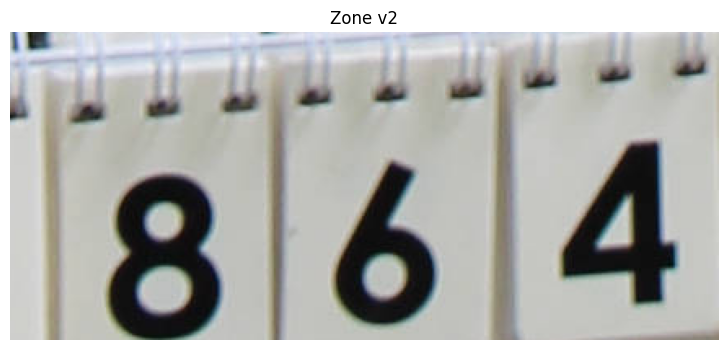

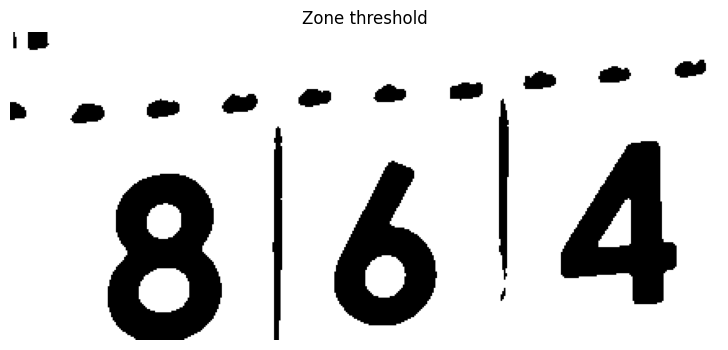

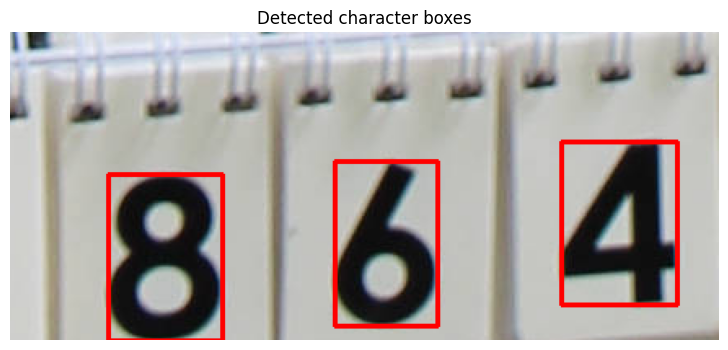

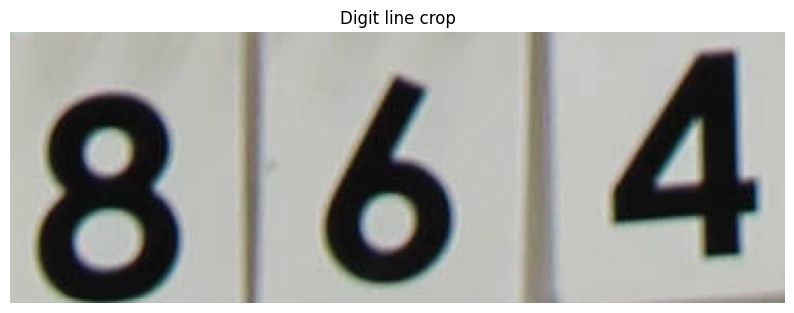

In [49]:
test_path = sample_paths[1]

image_bgr = cv2.imread(str(test_path))
det_res = model(str(test_path), verbose=False)[0]

bbox = det_res.boxes.xyxy.cpu().numpy()[0]

plate = crop_bbox(image_bgr, bbox)
plate = normalize_plate_orientation(plate)
zone = extract_number_zone_v2(plate)

digit_line_bgr, zone_thresh, boxes = extract_digit_line_from_zone(zone)
zone_boxes_img = draw_boxes_on_zone(zone, boxes)

show_image(cv2.cvtColor(zone, cv2.COLOR_BGR2RGB), title="Zone v2")
show_image(zone_thresh, title="Zone threshold", cmap="gray")
show_image(zone_boxes_img, title="Detected character boxes")
show_image(cv2.cvtColor(digit_line_bgr, cv2.COLOR_BGR2RGB), title="Digit line crop")

## OCR на digit_line_bgr

In [50]:
ocr_result = reader.readtext(digit_line_bgr)
ocr_result

[([[0, np.int32(1)], [375, np.int32(1)], [375, 131], [0, 131]],
  '816 4',
  np.float64(0.2591205698798505))]

In [51]:
raw_text, conf = extract_text_from_easyocr(ocr_result)
clean = process_ocr_text(raw_text)
norm = normalize_plate_number(clean)

print("RAW:", raw_text)
print("CLEAN:", clean)
print("NORMALIZED:", norm)
print("CONF:", conf)
print("EXPECTED:", extract_expected_number_from_filename(test_path.name))

RAW: 816 4
CLEAN: 8164
NORMALIZED: 8164
CONF: 0.2591205698798505
EXPECTED: 0864


- контуры отфильтрованы лучше;
- в boxes остались только 8, 6, 4;
- но в самом Digit line crop вертикальные разделители всё ещё видны между цифрами;
- EasyOCR всё равно читает одну из них как 1.

То есть проблема уже не в выборе боксов, а в том, что мы всё ещё даём OCR цельный crop с разделителями.

## Функция сборки строки из символов

In [52]:
def build_character_strip(zone_bgr, boxes, pad=10, gap=20):
    if not boxes:
        return None

    chars = []
    heights = []

    for x, y, bw, bh in boxes:
        crop = zone_bgr[y:y+bh, x:x+bw]
        chars.append(crop)
        heights.append(crop.shape[0])

    target_h = max(heights) + 2 * pad

    resized_chars = []
    total_w = gap

    for crop in chars:
        h, w = crop.shape[:2]
        scale = (target_h - 2 * pad) / h
        new_w = max(1, int(w * scale))
        resized = cv2.resize(crop, (new_w, target_h - 2 * pad), interpolation=cv2.INTER_CUBIC)
        resized_chars.append(resized)
        total_w += new_w + gap

    canvas = np.full((target_h, total_w, 3), 255, dtype=np.uint8)

    x_cursor = gap
    for crop in resized_chars:
        h, w = crop.shape[:2]
        y_offset = pad
        canvas[y_offset:y_offset+h, x_cursor:x_cursor+w] = crop
        x_cursor += w + gap

    return canvas

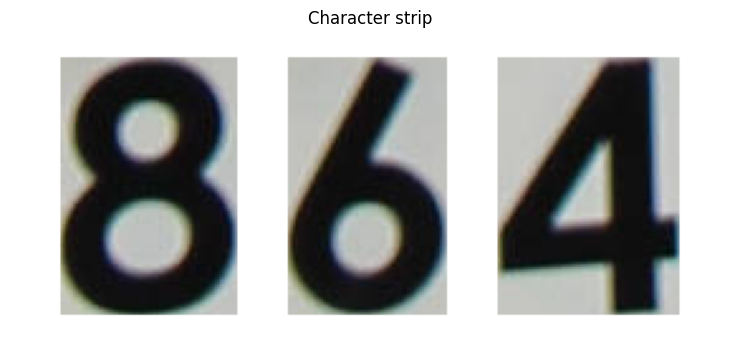

In [53]:
char_strip_bgr = build_character_strip(zone, boxes)
char_strip_rgb = cv2.cvtColor(char_strip_bgr, cv2.COLOR_BGR2RGB)

show_image(char_strip_rgb, title="Character strip")

In [54]:
raw_text, conf = extract_text_from_easyocr(ocr_result)
clean = process_ocr_text(raw_text)
norm = normalize_plate_number(clean)

print("RAW:", raw_text)
print("CLEAN:", clean)
print("NORMALIZED:", norm)
print("CONF:", conf)
print("EXPECTED:", extract_expected_number_from_filename(test_path.name))

RAW: 816 4
CLEAN: 8164
NORMALIZED: 8164
CONF: 0.2591205698798505
EXPECTED: 0864
